In [1]:
import sys
import os
from pathlib import Path
sys.path.insert(0, os.path.abspath('../..'))
from codes.lsd_train import LSD
from codes.config import LSDConfig
from codes.utils import plot_random_walks , cross_boundary_correctness, plot_z_components, visualize_random_walks_on_umap
import scanpy as sc
import scvelo as scv
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import numpy as np
import pandas as pd
import scipy.sparse as sp
import torch.nn as nn
import pyro
import cellrank as cr
# cellrank imports
from cellrank.kernels import ConnectivityKernel
from cellrank.kernels.utils import TmatProjection
from statistics import mean

In [2]:
# Configure computational device
# Using GPU for faster training (change to 'cpu' if no GPU available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# # Check GPU details if available
# if device.type == 'cuda':
#     print(f"GPU Name: {torch.cuda.get_device_name(1)}")
#     print(f"GPU Memory: {torch.cuda.get_device_properties(1).total_memory / 1e9:.2f} GB")

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
pyro.set_rng_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# Create output directory for figures
output_dir = Path("../Figures/Erythroid")
output_dir.mkdir(parents=True, exist_ok=True)
print(f"\nFigures will be saved to: {output_dir.absolute()}")

Using device: cuda

Figures will be saved to: /home/saberi/projects/lsd/LSD-main-branch/Notebooks/Erythroid/../Figures/Erythroid


In [3]:
# Load preprocessed single-cell data
# This dataset has already been normalized and includes:
# - Log-normalized gene expression in .X
# - Raw counts in .layers['raw']
# - Library sizes in .obs['librarysize']
# - Prior pseudotime in .obs['prior_pseudotime']
# - Cell type annotations in .obs['clusters']

adata = sc.read("/home/saberi/projects/lsd/data/Erythroid/normlized_before.h5ad")

print("Dataset loaded successfully!")
print(f"Number of cells: {adata.n_obs:,}")
print(f"Number of genes: {adata.n_vars:,}")
print(f"\nAvailable data layers: {list(adata.layers.keys())}")
print(f"Cell metadata columns: {list(adata.obs.columns)}")
print(f"\nCell type distribution:")
print(adata.obs['clusters'].value_counts().sort_index())

Dataset loaded successfully!
Number of cells: 9,815
Number of genes: 5,000

Available data layers: ['raw', 'spliced', 'unspliced']
Cell metadata columns: ['sample', 'stage', 'sequencing.batch', 'theiler', 'clusters', 'prior_pseudotime', 'librarysize', 'n_counts']

Cell type distribution:
clusters
Blood progenitors 1     623
Blood progenitors 2    2460
Erythroid1             2929
Erythroid2             1106
Erythroid3             2697
Name: count, dtype: int64


In [4]:
# Define the differentiation phylogeny
# This represents the known biological progression of erythroid differentiation
# Each key maps to its allowed successor cell types

phylogeny = {
    'Blood progenitors 1': ['Blood progenitors 2'],  # Early progenitors
    'Blood progenitors 2': ['Erythroid1'],           # Committed progenitors
    'Erythroid1': ['Erythroid2'],                    # Early erythroid
    'Erythroid2': ['Erythroid3'],                    # Intermediate erythroid
    'Erythroid3': []                                 # Mature erythroid (terminal state)
}

print("Differentiation phylogeny defined:")
for parent, children in phylogeny.items():
    if children:
        print(f"  {parent} → {', '.join(children)}")
    else:
        print(f"  {parent} (terminal state)")

Differentiation phylogeny defined:
  Blood progenitors 1 → Blood progenitors 2
  Blood progenitors 2 → Erythroid1
  Erythroid1 → Erythroid2
  Erythroid2 → Erythroid3
  Erythroid3 (terminal state)


In [5]:
# Initialize the LSD model
print("Initializing LSD model...")
cfg = LSDConfig()

cfg.model.V_coeff = 5e-3
cfg.optimizer.kl_schedule.af = 3
cfg.walks.batch_size = 256
cfg.walks.path_len = 16
cfg.walks.random_state = SEED
pyro.set_rng_seed(42)


lsd = LSD(
    adata,                           # Single-cell data
    cfg,
    device=device,                   # Computation device (GPU/CPU)
    lib_size_key="librarysize",      # Column name for library sizes
    raw_count_key="raw",             # Layer name for raw counts
)

print("Model initialized successfully!")
print(f"  Cell state dimension: {lsd.z_dim}")
print(f"  Differentiation state dimension: {lsd.B_dim}")

Initializing LSD model...
Model initialized successfully!
  Cell state dimension: 10
  Differentiation state dimension: 2


In [6]:
# Set phylogeny constraints and prior transitions
# This incorporates biological knowledge into the model

print("Setting phylogeny constraints...")
lsd.set_phylogeny(phylogeny, cluster_key="clusters")

print("\nSetting prior transition matrix from pseudotime...")
lsd.set_prior_transition(prior_time_key="prior_pseudotime")

print("\nBiological constraints successfully incorporated into model")

Setting phylogeny constraints...

Setting prior transition matrix from pseudotime...
[LSD] Removing 2 cells with no transitions:
[LSD] Prior transition matrix set from phylogeny and pseudotime.

Biological constraints successfully incorporated into model


Generating random walk trajectories...
Random walks generated successfully!
  Shape of walks: torch.Size([4096, 16])

Visualizing random walks on UMAP embedding...


/home/saberi/miniconda/envs/sclsd/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = scatter(


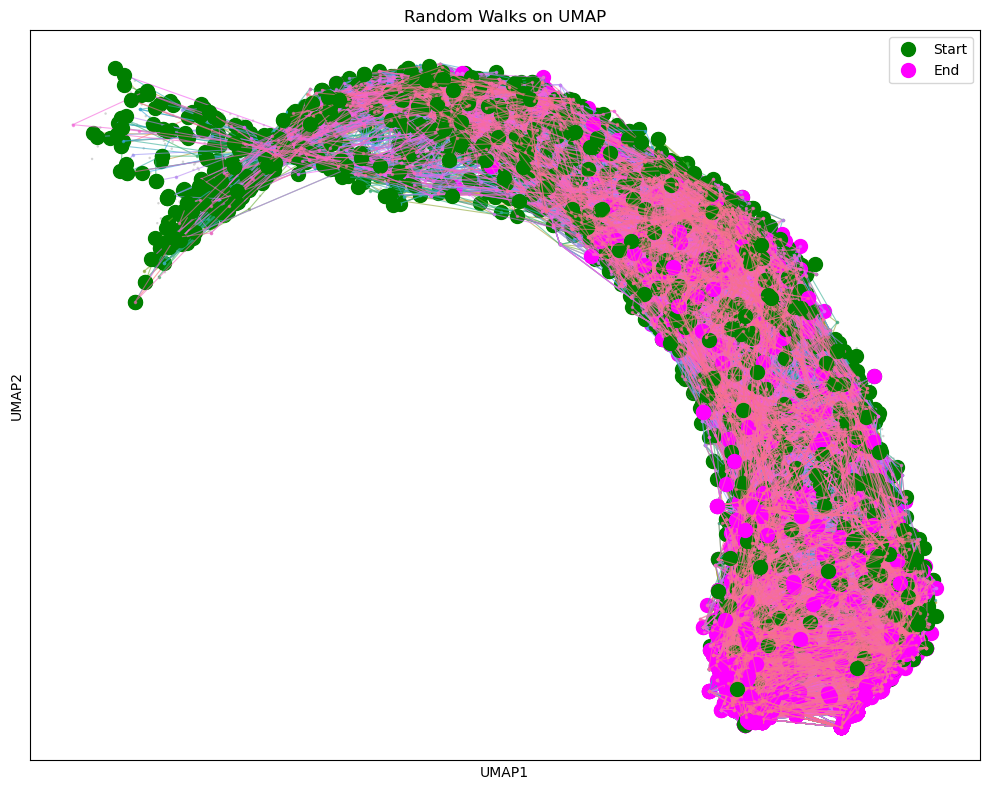

In [7]:
# Generate random walks on the cell connectivity graph
# These trajectories are used to train smooth dynamics

print(f"Generating random walk trajectories...")
lsd.prepare_walks()

print("Random walks generated successfully!")
print(f"  Shape of walks: {lsd.walks.shape}")

# Visualize a sample of random walks on UMAP
print("\nVisualizing random walks on UMAP embedding...")
plot_random_walks(lsd.adata, lsd.walks, "X_umap")


Pyro parameter store cleared
Model checkpoints will be saved to: ../../Models/Erythroid_model

Starting model training...
This may take 20-30 minutes depending on GPU



Training Epochs: 100%|██████████| 30/30 [02:14<00:00,  4.47s/it, -ELBO=7.2845, Potential Metric=0.5158, Entropy Metric=0.0338]


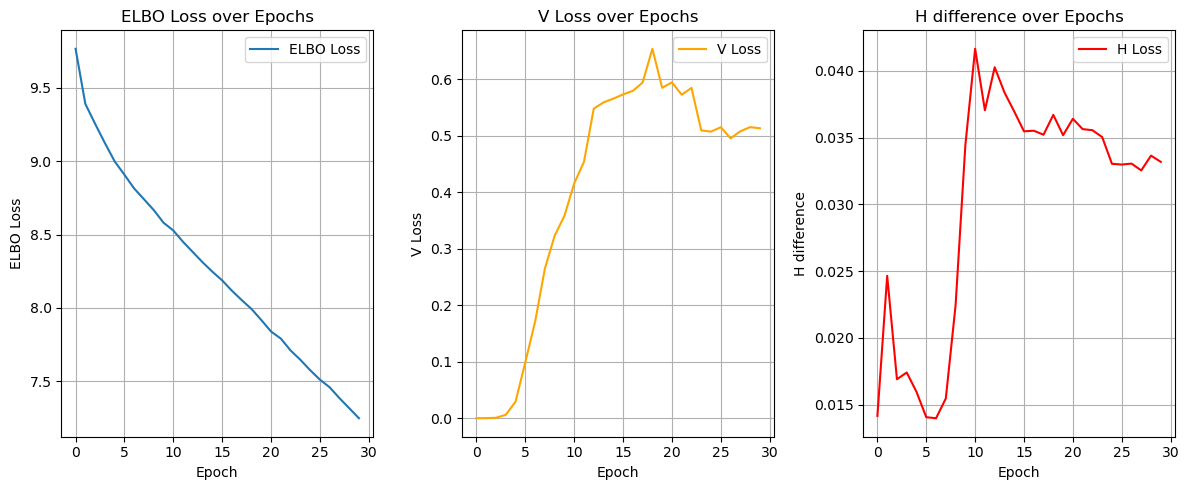


Training completed successfully!


In [8]:
# Clear any existing parameters from previous runs
pyro.clear_param_store()
print("Pyro parameter store cleared")

# Create save directory for model checkpoints
save_dir = "../../Models/Erythroid_model"
os.makedirs(save_dir, exist_ok=True)
print(f"Model checkpoints will be saved to: {save_dir}")

num_epochs = 30

print("\n" + "="*50)
print("Starting model training...")
print("="*50)
print("This may take 20-30 minutes depending on GPU")
print("")

# Train the model
lsd.train(
    num_epochs=num_epochs,      # Total training epochs
    save_dir=save_dir,          # Directory for checkpoints
    save_interval=15,           # Save model every 50 epochs
    random_state=42             # Random seed for reproducibility
)

print("\n" + "="*50)
print("Training completed successfully!")
print("="*50)